# Logistic Regression

In [41]:
# imports

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    RocCurveDisplay,
)


### 1. Settings


In [42]:
FEATURES_PATH = Path("outputs") / "eeg_features_data.csv"
OUTPUT_DIR = Path("outputs") # directory for outputs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True) # create output directory if it doesn't exist
FIGURES_DIR = OUTPUT_DIR / "figures"
TABS_DIR = OUTPUT_DIR / "tabs"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABS_DIR.mkdir(parents=True, exist_ok=True)

features_df = pd.read_csv(FEATURES_PATH)

In [43]:
# useful functions

def pretty_feature_name(feature):
    """
    Return a readable name for a feature.
    If the feature is not in FEATURE_LABELS, return the original name.
    """
    return FEATURE_LABELS.get(feature, feature) 

def save_figure(filename, dpi=300):
    """
    Save the current matplotlib figure inside outputs/figures.
    """
    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print("Figure saved to:", output_path)

def save_table(df, filename, index=False):
    """
    Save a pandas DataFrame inside outputs/tabs.
    """
    output_path = TABS_DIR / filename
    df.to_csv(output_path, index=index)
    print("Table saved to:", output_path)


def tune_logistic_regression(
    X_train,
    y_train,
    model_name
):
    """
    Tune Logistic Regression using cross-validation on the training set.
    Scaling is included inside the pipeline to avoid data leakage.
    """

    logreg_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    param_grid = {
        "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "classifier__penalty": ["l2"],
        "classifier__solver": ["lbfgs"]
    }

    grid_search = GridSearchCV(
        estimator=logreg_pipeline,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    print(f"\n{model_name}")
    print("Best Logistic Regression parameters:")
    print(grid_search.best_params_)
    print("Best CV balanced accuracy:")
    print(grid_search.best_score_)

    results_df = pd.DataFrame(
        grid_search.cv_results_
    ).sort_values("rank_test_score")

    save_table(
        results_df,
        f"2b_logreg_{model_name}_grid_search_results.csv"
    )

    best_params_df = pd.DataFrame([grid_search.best_params_])
    best_params_df["best_cv_balanced_accuracy"] = grid_search.best_score_

    save_table(
        best_params_df,
        f"2b_logreg_{model_name}_best_params.csv"
    )

    display(best_params_df)

    return grid_search

def evaluate_final_model_on_test_set(
    fitted_model,
    X_train,
    y_train,
    X_test,
    y_test,
    feature_set_name,
    n_features,
    output_prefix,
    extra_info=None
):
    """
    Train the selected model on the training set
    and evaluate it once on the test set.
    """

    fitted_model.fit(X_train, y_train)

    y_test_pred = fitted_model.predict(X_test)
    y_test_proba = fitted_model.predict_proba(X_test)[:, 1]

    final_results = {
        "feature_set": feature_set_name,
        "n_features": n_features,
        "accuracy": accuracy_score(y_test, y_test_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred),
        "recall": recall_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred),
        "roc_auc": roc_auc_score(y_test, y_test_proba)
    }

    if extra_info is not None:
        final_results.update(extra_info)

    final_results_df = pd.DataFrame([final_results])

    save_table(
        final_results_df,
        f"{output_prefix}_test_metrics.csv"
    )

    display(final_results_df)

    # ROC curve
    plt.figure(figsize=(6, 6))

    RocCurveDisplay.from_predictions(
        y_test,
        y_test_proba,
        name=feature_set_name
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="black",
        linewidth=1,
        label="Chance"
    )

    plt.title(f"ROC curve on final test set\n{feature_set_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.grid(
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()

    save_figure(
        f"{output_prefix}_roc_curve.png"
    )

    plt.show()

    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        y_test_pred,
        labels=[0, 1]
    )

    cm_df = pd.DataFrame(
        cm,
        index=["True Control", "True ADHD"],
        columns=["Predicted Control", "Predicted ADHD"]
    )

    save_table(
        cm_df,
        f"{output_prefix}_confusion_matrix.csv",
        index=True
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Control", "ADHD"]
    )

    disp.plot(cmap="Greens")

    plt.title(f"Final test confusion matrix\n{feature_set_name}")

    plt.tight_layout()

    save_figure(
        f"{output_prefix}_confusion_matrix.png"
    )

    plt.show()

    display(cm_df)

    # Classification report
    report_dict = classification_report(
        y_test,
        y_test_pred,
        target_names=["Control", "ADHD"],
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).T

    save_table(
        report_df,
        f"{output_prefix}_classification_report.csv",
        index=True
    )

    display(report_df)

    return final_results_df, fitted_model, y_test_pred, y_test_proba


In [44]:
# train/test split

train_df, test_df = train_test_split(
    features_df,
    test_size=0.20,
    stratify=features_df["Class"],
    random_state=42
)

# define target variable

y_train = train_df["Class"].map({
    "Control": 0,
    "ADHD": 1
})

y_test = test_df["Class"].map({
    "Control": 0,
    "ADHD": 1
})

In [45]:
metadata_cols = [
    "ID",
    "Class",
    "n_samples",
    "duration_sec"
]

all_feature_cols = [
    c for c in features_df.columns
    if c not in metadata_cols
]

all_feature_cols = [
    c for c in all_feature_cols
    if pd.api.types.is_numeric_dtype(features_df[c])
]

regional_feature_cols = [
    c for c in all_feature_cols
    if (
        c.startswith("frontal_")
        or c.startswith("central_")
        or c.startswith("temporal_")
        or c.startswith("parietal_")
        or c.startswith("occipital_")
    )
]

In [46]:
cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

In [47]:
best_feature_set_name = "Regional mean features"
best_feature_cols = regional_feature_cols

In [48]:
reduced_features_df = pd.read_csv(
    TABS_DIR / "2a_rf_final_reduced_selected_features.csv"
)

final_reduced_feature_cols = reduced_features_df["selected_feature"].tolist()

In [49]:
tbr_features_df = pd.read_csv(
    TABS_DIR / "2a_rf_theta_beta_ratio_selected_features.csv"
)

best_tbr_feature_cols = tbr_features_df["selected_feature"].tolist()
best_tbr_feature_set_name = "Theta/beta ratio feature set"


original_best_feature_set
Best Logistic Regression parameters:
{'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV balanced accuracy:
0.6133333333333333
Table saved to: outputs\tabs\2b_logreg_original_best_feature_set_grid_search_results.csv
Table saved to: outputs\tabs\2b_logreg_original_best_feature_set_best_params.csv


,classifier__C,classifier__penalty,classifier__solver,best_cv_balanced_accuracy
0,0.1,l2,lbfgs,0.613333


Table saved to: outputs\tabs\2b_logreg_original_best_feature_set_test_metrics.csv


,feature_set,n_features,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Logistic Regression - Regional mean features,25,0.6,0.596154,0.6,0.692308,0.642857,0.615385


Figure saved to: outputs\figures\2b_logreg_original_best_feature_set_roc_curve.png


<Figure size 600x600 with 0 Axes>

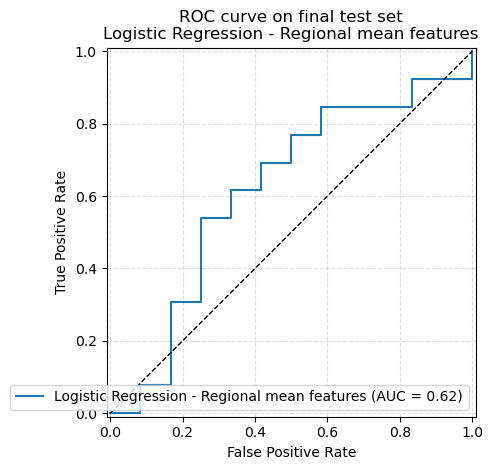

Table saved to: outputs\tabs\2b_logreg_original_best_feature_set_confusion_matrix.csv
Figure saved to: outputs\figures\2b_logreg_original_best_feature_set_confusion_matrix.png


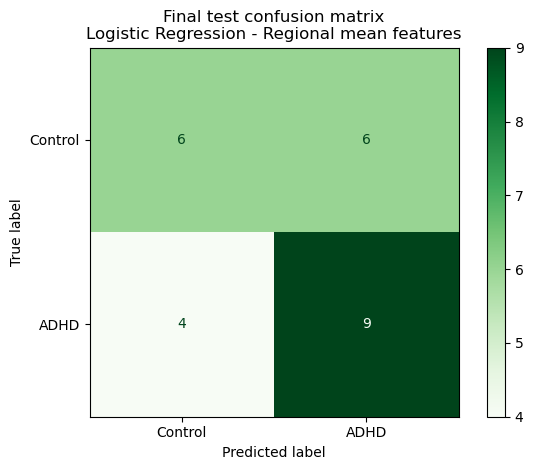

,Predicted Control,Predicted ADHD
True Control,6,6
True ADHD,4,9


Table saved to: outputs\tabs\2b_logreg_original_best_feature_set_classification_report.csv


,precision,recall,f1-score,support
Control,0.6,0.500000,0.545455,12.0
ADHD,0.6,0.692308,0.642857,13.0
accuracy,0.6,0.600000,0.600000,0.6
macro avg,0.6,0.596154,0.594156,25.0
weighted avg,0.6,0.600000,0.596104,25.0


In [50]:
X_train_best = train_df[best_feature_cols]
X_test_best = test_df[best_feature_cols]

logreg_original_grid_search = tune_logistic_regression(
    X_train_best,
    y_train,
    "original_best_feature_set"
)

logreg_original_test_results_df, logreg_original_model, logreg_original_y_pred, logreg_original_y_proba = evaluate_final_model_on_test_set(
    fitted_model=logreg_original_grid_search.best_estimator_,
    X_train=X_train_best,
    y_train=y_train,
    X_test=X_test_best,
    y_test=y_test,
    feature_set_name=f"Logistic Regression - {best_feature_set_name}",
    n_features=len(best_feature_cols),
    output_prefix="2b_logreg_original_best_feature_set"
)